<a href="https://colab.research.google.com/github/Imposon/Trial/blob/main/Copy_of_Question_State_Management_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Notebook Overview

* **Goal:** Build a stateful AI Dungeon Text Adventure Game to understand why LangGraph is needed for multi-turn LLM applications.

**Workflow:**
1. Install dependencies and configure the Groq LLM
2. Demonstrate the stateless problem with a plain LangChain chain
3. Define a typed state schema (`GameState`) and graph node functions
4. Build and compile the graph, then run multi-turn play
5. Add conditional routing for game-over and victory outcomes
6. Compare LangChain vs LangGraph side-by-side

**Key Concepts:**
- `TypedDict` state schema shared across all graph nodes
- `operator.add` annotation for append-only list fields
- Node functions that return only the fields they update
- Conditional edges that branch based on runtime state

**Documentation:**
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [Groq API Documentation](https://console.groq.com/docs)
- [LangChain Core Messages](https://python.langchain.com/docs/concepts/messages/)

## 1. Setup

* **Install and Import:** This cell installs required packages and configures the Groq LLM client used throughout the notebook.

**Hints:**
- `TypedDict` defines the typed state dictionary used as the graph schema
- `Annotated` combined with `operator.add` enables append-only list fields
- `Literal` constrains routing function return types to a fixed set of strings
- `StateGraph` is the core LangGraph class that wires nodes and edges together

**What each import does:**

| Import | Description |
|--------|-------------|
| `TypedDict` | Defines a typed dictionary class used as the graph state schema |
| `Annotated` | Attaches metadata to a type -- used with `operator.add` to enable list appending |
| `Literal` | Restricts a type to specific string values -- used in routing functions |
| `ChatGroq` | Groq-hosted LLM client compatible with LangChain interfaces |
| `HumanMessage` / `SystemMessage` | Message types for structuring LLM prompts |
| `StateGraph` | LangGraph class that builds a directed graph of nodes and edges |
| `START` / `END` | Sentinel constants marking the entry and exit of the graph |

**Documentation:**
- [StateGraph](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.StateGraph)
- [ChatGroq](https://python.langchain.com/docs/integrations/chat/groq/)
- [Python typing -- TypedDict](https://docs.python.org/3/library/typing.html#typing.TypedDict)

In [ ]:
%pip install -q langgraph langchain-groq langchain-core langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
import os, getpass, operator
from typing import TypedDict, Annotated, Literal
from google.colab import userdata

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END, START

# -- Configure Groq --
if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7)  # hint: Groq LLM client class

# Quick test
print(llm.invoke([HumanMessage(content="Say 'ready' and nothing else.")]).content)

/Users/ankushbisht/Documents/Gen AI Labs/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


ready


## 2. The Problem -- Stateless LangChain Chains

* **Stateless Demo:** This cell builds a plain LangChain chain acting as a dungeon game master, then calls it three times with sequential actions to expose its amnesia.

**Hints:**
- Each `invoke` call is completely independent -- no memory of prior calls
- Turn 2 references the cave from turn 1, but the chain has no record of it
- This limitation is the core reason LangGraph exists

**What each piece does:**

| Component | Description |
|-----------|-------------|
| `ChatPromptTemplate.from_messages([...])` | Builds a reusable prompt template from a list of role/content pairs |
| `template \| llm` | LangChain pipe operator -- chains prompt formatting into LLM invocation |
| `chain.invoke({"key": value})` | Runs one independent call with the given input -- no shared state between calls |

**Documentation:**
- [ChatPromptTemplate](https://python.langchain.com/docs/concepts/prompt_templates/)
- [LangChain Expression Language (LCEL)](https://python.langchain.com/docs/concepts/lcel/)

In [ ]:
stateless_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "You are a dungeon game master. Describe what happens in 2 sentences."),
        ("human", "Player action: {action}"),
    ])
    | llm
)

actions = [
    "I look around the dark forest and find a cave.",
    "I enter the cave I found earlier.",           # References turn 1
    "I pick up the torch from the cave wall.",     # References turn 2
]

print("LANGCHAIN (Stateless) -- Each call is independent\n")
for i, action in enumerate(________, 1):
    resp = stateless_chain.________({"action": action})  # hint: method to run the chain with input values
    print(f"Turn {i}: {action}\n  >> {resp.content}\n")

LANGCHAIN (Stateless) -- Each call is independent

Turn 1: I look around the dark forest and find a cave.
  >> As you approach the cave, you notice that the entrance is shrouded in a faint, eerie glow emanating from within, and the air surrounding it seems to be heavy with the scent of damp earth and decaying leaves. A rustling noise echoes from deeper within the cave, followed by the faint sound of scuttling footsteps, making it seem as though something is watching you from just out of sight.

Turn 2: I enter the cave I found earlier.
  >> As you step into the darkness of the cave, the creaking of the old wooden door echoes behind you, and the faint glow of luminescent mushrooms on the walls casts an eerie light on the rough, damp stone floor, revealing a narrow passageway that stretches deep into the depths of the cave. The air inside is musty and stale, filled with the scent of damp earth and something else - a faint hint of something metallic and mysterious that seems to be calling

## 3. State Schema -- GameState

* **State Schema:** This cell defines the `GameState` typed dictionary that every node in the graph reads from and writes to. It is the single source of truth for the entire game.

**Hints:**
- Nodes return only the fields they update -- all other fields remain unchanged
- The `history` field uses a special annotation so entries are appended, not replaced
- `operator.add` is the reducer function that merges two lists by concatenating them

**What each field does:**

| Field | Type | Description |
|-------|------|-------------|
| `player_name` | `str` | The adventurer's name, set at game start |
| `location` | `str` | Current in-game location, updated by `process_action` each turn |
| `health` | `int` | Player HP (0--100); reaching 0 triggers the game-over route |
| `inventory` | `list[str]` | Items the player is carrying, updated by `process_action` |
| `history` | `Annotated[list[str], operator.add]` | Append-only story log -- new entries are added, never replaced |
| `last_action` | `str` | The player's most recent command, injected before each graph run |
| `turn` | `int` | Turn counter, incremented by the `tick` node |
| `game_over` | `bool` | Flag set to `True` when health reaches 0 |

**Documentation:**
- [Python typing -- TypedDict](https://docs.python.org/3/library/typing.html#typing.TypedDict)
- [LangGraph state reducers](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)
- [operator.add](https://docs.python.org/3/library/operator.html#operator.add)

In [ ]:
# -- Step 1: Define the state schema --

class GameState(TypedDict):
    player_name: ___
    location: ___
    health: int
    inventory: list[str]
    history: Annotated[list[str], ________]   # hint: reducer function that combines lists by appending new entries
    last_action: ______
    turn: ____
    game_over: bool

## 4. Node Functions

* **Graph Nodes:** Each node is a plain Python function that receives the full `GameState` and returns a dictionary containing **only** the fields it wants to update. LangGraph merges that partial dictionary back into the state automatically.

**Hints:**
- `narrate` calls the LLM to write a scene description and appends the result to `history`
- `process_action` asks the LLM to parse location, health change, and item pickup from the player's action
- `tick` increments the turn counter and sets `game_over` if health has reached zero
- Health must be clamped to stay within the valid 0--100 range using `max` and `min`

**What each node returns:**

| Node | Returns | Description |
|------|---------|-------------|
| `narrate` | `{"history": [...]}` | Appends one new narration entry to the story log |
| `process_action` | `{"location": ..., "health": ..., "inventory": ...}` | Updates world state based on the parsed action |
| `tick` | `{"turn": ..., "game_over": ...}` | Advances the turn counter and checks the win/loss condition |

**Documentation:**
- [LangGraph nodes](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes)
- [SystemMessage / HumanMessage](https://python.langchain.com/docs/concepts/messages/)

In [ ]:
# -- Step 2: Define node functions --
# Each node receives the full state and returns ONLY the fields it wants to update.

def narrate(state: GameState) -> dict:
    """Use the LLM to narrate the scene based on full game state."""
    recent = "\n".join(state["history"][-3:]) if state["history"] else "Adventure begins."
    resp = llm.invoke([
        SystemMessage(content=(
            "You are a dungeon game master. Narrate in 2-3 sentences using second person. "
            "Be consistent with the story history, location, and inventory."
        )),
        HumanMessage(content=(
            f"Player: {state['player_name']} | Location: {state['location']} | "
            f"HP: {state['health']}/100 | Inventory: {state['inventory'] or ['empty']}\n"
            f"Action: {state['last_action']}\nRecent story:\n{recent}"
        )),
    ])
    return {"________": [f"[Turn {state['turn']+1}] {resp.content.strip()}"]}  # hint: the only state field this node updates


def process_action(state: GameState) -> dict:
    """Use the LLM to determine game-state changes from the player's action."""
    resp = llm.invoke([
        SystemMessage(content=(
            "You are a game engine. Given the action, respond in EXACTLY this format:\n"
            "LOCATION: <new place or SAME>\nHEALTH_CHANGE: <int like -10, +5, or 0>\n"
            "ITEM: <item name or NONE>"
        )),
        HumanMessage(content=(
            f"Location: {state['location']} | HP: {state['health']} | "
            f"Inventory: {state['inventory']}\nAction: {state['last_action']}"
        )),
    ])
    loc, hp_delta, item = state["location"], 0, None
    for line in resp.content.strip().split("\n"):
        if line.upper().startswith("LOCATION:"):
            v = line.split(":", 1)[1].strip()
            if v.upper() != "SAME": loc = v
        elif line.upper().startswith("HEALTH_CHANGE:"):
            try: hp_delta = int(line.split(":", 1)[1].strip().replace("+", ""))
            except ValueError: pass
        elif line.upper().startswith("ITEM:"):
            v = line.split(":", 1)[1].strip()
            if v.upper() != "NONE": item = v

    inv = list(state["inventory"])
    if item: inv.append(item)
    return {
        "location": loc,
        "health": ________(________, ________(________, state["health"] + hp_delta)),  # hint: clamp health -- lower bound 0, upper bound 100
        "inventory": inv
    }


def tick(state: GameState) -> dict:
    """Increment turn counter and check for game over."""
    return {"turn": state["turn"] + ________, "game_over": state["________"] <= 0}  # hint: increment value; which field drops to 0 when the player dies

## 5. Build and Compile the Graph

* **Graph Assembly:** This cell wires the three nodes together with directed edges, then compiles the graph into a runnable object.

**Hints:**
- `add_node` registers a Python function as a named callable node
- `add_edge` creates a fixed directional connection between two nodes
- The graph must start from `START` and must have a path leading to `END`
- `compile()` validates the structure and returns a `CompiledGraph` ready for invocation

**What each method does:**

| Method | Description |
|--------|-------------|
| `StateGraph(GameState)` | Creates a new graph using `GameState` as its state schema |
| `add_node(name, fn)` | Registers `fn` as a node callable accessible by `name` |
| `add_edge(from_node, to_node)` | Adds a fixed directional edge between two nodes |
| `compile()` | Validates the graph and returns a runnable `CompiledGraph` object |
| `get_graph().draw_mermaid_png()` | Renders the graph topology as a Mermaid diagram image |

**Documentation:**
- [StateGraph.add_node](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.StateGraph.add_node)
- [StateGraph.compile](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.StateGraph.compile)

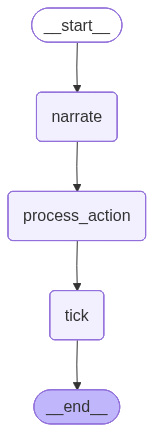

In [ ]:
# -- Step 3: Build and compile the graph --

graph = ________(GameState)  # hint: LangGraph class that builds a stateful directed graph
graph.add_node("narrate", ________)         # hint: function for this node
graph.add_node("process_action", ________)  # hint: function for this node
graph.add_node("tick", ________)            # hint: function for this node

graph.add_edge(________, "narrate")         # hint: graph entry sentinel constant
graph.add_edge(__________, "process_action") # hint: add edge between naration and process_action
graph.add_edge("process_action", _________) # hint: add edge between process action and tick
graph.add_edge("tick", ________)            # hint: graph exit sentinel constant

game = graph.______()  # hint: method that validates the graph and returns an executable object

# Visualize
from IPython.display import Image, display
try:
    display(Image(game.get_graph().draw_mermaid_png()))
except Exception:
    print(game.get_graph().draw_mermaid())

## 6. Multi-Turn Execution -- State Persists

* **Stateful Play:** This cell runs four sequential player actions through the compiled graph. After each turn, the full output state is fed back as input -- location, inventory, health, and history all carry forward automatically.

**Hints:**
- Initialize the state dictionary with all `GameState` fields before the first turn
- Set `last_action` before each `invoke` call -- this is how the player's command enters the graph
- `game.invoke(state)` returns the complete updated state after all nodes have run
- Notice how the LLM narration in later turns references events from earlier turns

**What each step does:**

| Step | Description |
|------|-------------|
| `state = { ... }` | Initializes the starting game state with all required fields |
| `state["last_action"] = action` | Injects the player's command into the state before each graph run |
| `game.invoke(state)` | Runs one full graph pass: `narrate` -> `process_action` -> `tick` |
| `state["history"][-1]` | Retrieves the most recently appended narration entry |

**Documentation:**
- [CompiledGraph.invoke](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.CompiledGraph.invoke)

In [ ]:
state = {
    "player_name": "Aldric",
    "location": "________",   # hint: describe an atmospheric starting location string
    "health": ________,       # hint: player starts at full health (integer between 0 and 100)
    "inventory": [],
    "history": [],
    "last_action": "",
    "turn": 0,
    "game_over": False,
}

actions = [
    "look around the dark forest and find a cave",
    "enter the cave I found earlier",
    "pick up the torch from the cave wall",
    "fight the goblin guarding the chest",
]

print("LANGGRAPH (Stateful) -- State carries forward\n")
for action in actions:
    state["________"] = action  # hint: state field where the player's command is stored
    state = game.________(state)  # hint: method to run one full graph pass and return updated state
    print(f"Turn {state['turn']}: {action}")
    print(f"  Location  : {state['location']}")
    print(f"  Health    : {state['health']}/100")
    print(f"  Inventory : {state['inventory'] or ['empty']}")
    print(f"  Narration : {state['history'][-1][:150]}...")
    print()

LANGGRAPH (Stateful) -- State carries forward

Turn 1: look around the dark forest and find a cave
  Location  : Dark Forest Cave Entrance
  Health    : 100/100
  Inventory : ['empty']
  Narration : [Turn 1] You stand at the edge of the Dark Forest, the dense foliage casting long shadows that stretch across the ground like skeletal fingers. A fain...

Turn 2: enter the cave I found earlier
  Location  : Dark Forest Cave | HEALTH_CHANGE: -0
  Health    : 100/100
  Inventory : ['TORN MAP']
  Narration : [Turn 2] As you step into the cave, the darkness envelops you, and the air grows stale. You fumble in your inventory, but it's still empty, a reminder...

Turn 3: pick up the torch from the cave wall
  Location  : Dark Forest Cave | HEALTH_CHANGE: -0
  Health    : 100/100
  Inventory : ['TORN MAP', 'TORCH']
  Narration : [Turn 3] You feel a surge of relief as you grasp the torch, a crude, iron-bound stick with a wick of dry, smoldering cloth, which casts flickering sha...

Turn 4: fight t

## 7. Conditional Routing -- Branching Based on State

* **Dynamic Branching:** This cell adds two terminal nodes and a routing function that inspects the state after every tick to decide which path the graph takes next -- a feature impossible with linear LangChain pipes.

**Hints:**
- A routing function returns a string that matches one of the keys in the conditional edge mapping
- Check `health <= 0` first for game over; check the `inventory` for a specific keyword for victory
- `add_conditional_edges` replaces a fixed `tick -> END` edge with a runtime decision
- The `"__end__"` key maps to `END` and is returned when the game should continue to the next turn

**What each component does:**

| Component | Description |
|-----------|-------------|
| `game_over_node` | Terminal node -- LLM generates a dramatic death scene and sets `game_over: True` |
| `victory_node` | Terminal node -- LLM generates a triumphant win scene and sets `game_over: True` |
| `route(state)` | Routing function -- inspects state and returns a string key for the next node |
| `add_conditional_edges(from, fn, mapping)` | Calls `fn(state)` after `from` and follows the matched edge in `mapping` |

**Documentation:**
- [StateGraph.add_conditional_edges](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.StateGraph.add_conditional_edges)
- [LangGraph conditional routing](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)

In [ ]:
# -- Terminal nodes --

def game_over_node(state: GameState) -> dict:
    resp = llm.invoke([
        SystemMessage(content="Write a 2-sentence dramatic death scene in second person."),
        HumanMessage(content=f"Location: {state['location']}, Action: {state['last_action']}"),
    ])
    return {"history": [f"[GAME OVER] {resp.content.strip()}"], "game_over": True}

def victory_node(state: GameState) -> dict:
    resp = llm.invoke([
        SystemMessage(content="Write a 2-sentence victory scene in second person."),
        HumanMessage(content=f"Inventory: {state['inventory']}"),
    ])
    return {"history": [f"[VICTORY] {resp.content.strip()}"], "game_over": True}


# -- Routing function --

def route(state: GameState) -> Literal["game_over_node", "victory_node", "__end__"]:
    if state["________"] <= 0:   # hint: field that tracks player vitality
        return "________"        # hint: string key for the death terminal node
    if any("________" in item.lower() for item in state["inventory"]):  # hint: item keyword that signals the player has won
        return "________"        # hint: string key for the win terminal node
    return "__end__"


# -- Build the enhanced graph --

g2 = StateGraph(GameState)
g2.add_node("narrate", narrate)
g2.add_node("process_action", process_action)
g2.add_node("tick", tick)
g2.add_node("game_over_node", game_over_node)
g2.add_node("victory_node", victory_node)

g2.add_edge(START, "narrate")
g2.add_edge("narrate", "process_action")
g2.add_edge("process_action", "tick")
g2.add_conditional_edges("tick", ________, {  # hint: the routing function defined above
    "game_over_node": "game_over_node",
    "victory_node": "victory_node",
    "__end__": END,
})
g2.add_edge("game_over_node", END)
g2.add_edge("victory_node", END)

game_v2 = g2.______()  # hint: method that finalizes and returns a runnable graph

try:
    display(Image(game_v2.get_graph().draw_mermaid_png()))
except Exception:
    print(game_v2.get_graph().draw_mermaid())

### 5.1 Test -- Combat Until Game Over

We start the player at low health and run combat actions. The graph will automatically route to `game_over_node` when health hits zero.

In [ ]:
state = {
    "player_name": "Aldric", "location": "Goblin Fortress",
    "health": 40, "inventory": ["rusty sword"], "history": [],
    "last_action": "", "turn": 0, "game_over": False,
}

combat = ["fight the goblin patrol", "charge the orc warlord", "fight the dragon"]

for action in combat:
    if state["________"]:  # hint: boolean field set to True when the player has died or won
        break
    state["last_action"] = action
    state = game_v2.invoke(state)
    print(f"Turn {state['turn']}: {action} | HP: {state['health']}/100 | Game Over: {state['game_over']}")

print(f"\nFinal story:\n")
for entry in state["________"]:  # hint: field that stores all narration entries in order
    print(f"  {entry}\n")

## 8. Side-by-Side Comparison

| Feature | LangChain (Stateless Chain) | LangGraph (Stateful Graph) |
|---------|---------------------------|---------------------------|
| **State** | None -- each call is independent | Explicit typed schema shared across all nodes |
| **Control flow** | Linear pipe: `prompt \| llm \| parser` | Directed graph with conditional branching |
| **Multi-turn** | Must manually re-inject history | History accumulated automatically via `operator.add` |
| **Conditional logic** | External if/else around chain calls | Built-in `add_conditional_edges` on the graph |
| **Debuggability** | Inspect prompt and response only | Print full state at any node boundary |
| **Visualization** | Not supported | Built-in Mermaid diagram rendering |
| **Best for** | Single-shot tasks (summarize, translate, QA) | Multi-step agents, chatbots, games, workflows |

## 9. Challenge Exercise

**Task:** Add an `inventory_manager` node to the graph that:
1. Parses the player's action to detect "pick up", "drop", or "use" commands
2. Updates the `inventory` list accordingly
3. If the player uses a "health potion", removes it from inventory and heals +25 HP

Then add a conditional edge: if the player has a "magic key", route to a new `secret_room` node before continuing.

Use the scaffold below. Uncomment the assertions at the end to validate your solution.

In [ ]:
# TODO: Implement this node
def inventory_manager(state: GameState) -> dict:
    """Parse the action for inventory changes. Return updated inventory and health."""
    # YOUR CODE HERE
    pass

# TODO: Implement this node
def secret_room(state: GameState) -> dict:
    """Generate a description of a secret chamber unlocked by the magic key."""
    # YOUR CODE HERE
    pass

# TODO: Implement the routing function
def route_inventory(state: GameState) -> Literal["secret_room", "tick"]:
    """Route to secret_room if 'magic key' is in inventory, else to tick."""
    # YOUR CODE HERE
    pass

# TODO: Build graph_v3 with the new nodes wired in
# graph_v3 = StateGraph(GameState)
# ... add nodes, edges, conditional edges ...
# game_v3 = graph_v3.compile()

# -- Validation (uncomment after implementing) --
# test = {"player_name": "T", "location": "X", "health": 50, "inventory": ["magic key"],
#          "history": [], "last_action": "look", "turn": 0, "game_over": False}
# assert route_inventory(test) == "secret_room"
# test["inventory"] = []
# assert route_inventory(test) == "tick"
# print("[OK] All assertions passed.")

---

## Summary

**What you learned:**
- Stateless LangChain chains cannot maintain context across multiple calls
- LangGraph introduces an explicit `TypedDict` state schema shared across all graph nodes
- Nodes are pure functions: they receive state, return partial updates
- `operator.add` annotations enable append-only fields (e.g., conversation history)
- Conditional edges allow dynamic branching based on runtime state values
- The graph can be compiled, visualized, and debugged as a first-class object

**When to use which:**
- **LangChain** -- single-shot tasks: summarization, translation, code generation, question answering
- **LangGraph** -- multi-step, stateful workflows: agents, chatbots, game engines, approval pipelines

**Resources:**
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [Groq API Documentation](https://console.groq.com/docs)